# Feed-forward neural networks

A feed-forward network (multilayer perceptron, MLP) stacks linear layers with non-linear activations in between:

$$h_1 = \mathrm{ReLU}(W_1 x + b_1), \quad h_2 = \mathrm{ReLU}(W_2 h_1 + b_2), \quad \dots, \quad \text{logits} = W_L h_{L-1} + b_L .$$

Without the activations the whole stack would collapse into a single linear map; with them, the network can represent curved decision boundaries.

This notebook:

1. visualizes what an MLP learns on 2D toy problems, and how the decision boundary depends on the data and on the size of the network;
2. builds a complete training pipeline for handwritten digit recognition (MNIST), with a validation set, learning curves, a small hyperparameter search and a final test evaluation.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
torch.set_num_threads(8)
plt.rcParams["figure.dpi"] = 100

## 1. Decision boundaries in two dimensions

We start with two Gaussian clouds of 250 points each, centred at $(-1, 1)$ and $(1, -1)$ with standard deviation 0.5.

In [2]:
def gaussian_classes(means, std, n_per_class, seed=0):
    rng = np.random.default_rng(seed)
    X = np.vstack([rng.normal(m, std, size=(n_per_class, 2)) for m in means])
    y = np.repeat(np.arange(len(means)), n_per_class)
    return X.astype(np.float32), y

def mlp(hidden=(16,), n_in=2, n_out=2):
    layers, size = [], n_in
    for h in hidden:
        layers += [nn.Linear(size, h), nn.ReLU()]
        size = h
    return nn.Sequential(*layers, nn.Linear(size, n_out))

def fit(model, X, y, epochs=500, lr=0.01):
    X_t, y_t = torch.from_numpy(X), torch.from_numpy(y)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X_t), y_t)
        loss.backward()
        optimizer.step()
    accuracy = (model(X_t).argmax(1) == y_t).float().mean().item()
    return model, accuracy

def plot_boundary(ax, model, X, y, title, lim=3):
    xx, yy = np.meshgrid(np.linspace(-lim, lim, 300), np.linspace(-lim, lim, 300))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))
    with torch.no_grad():
        prob = torch.softmax(model(grid), 1)[:, 1].reshape(xx.shape).numpy()
    ax.contourf(xx, yy, prob, levels=20, cmap="RdBu", alpha=0.7, vmin=0, vmax=1)
    ax.contour(xx, yy, prob, levels=[0.5], colors="black", linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="white", s=15, linewidth=0.4)
    ax.set(title=title, xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal")

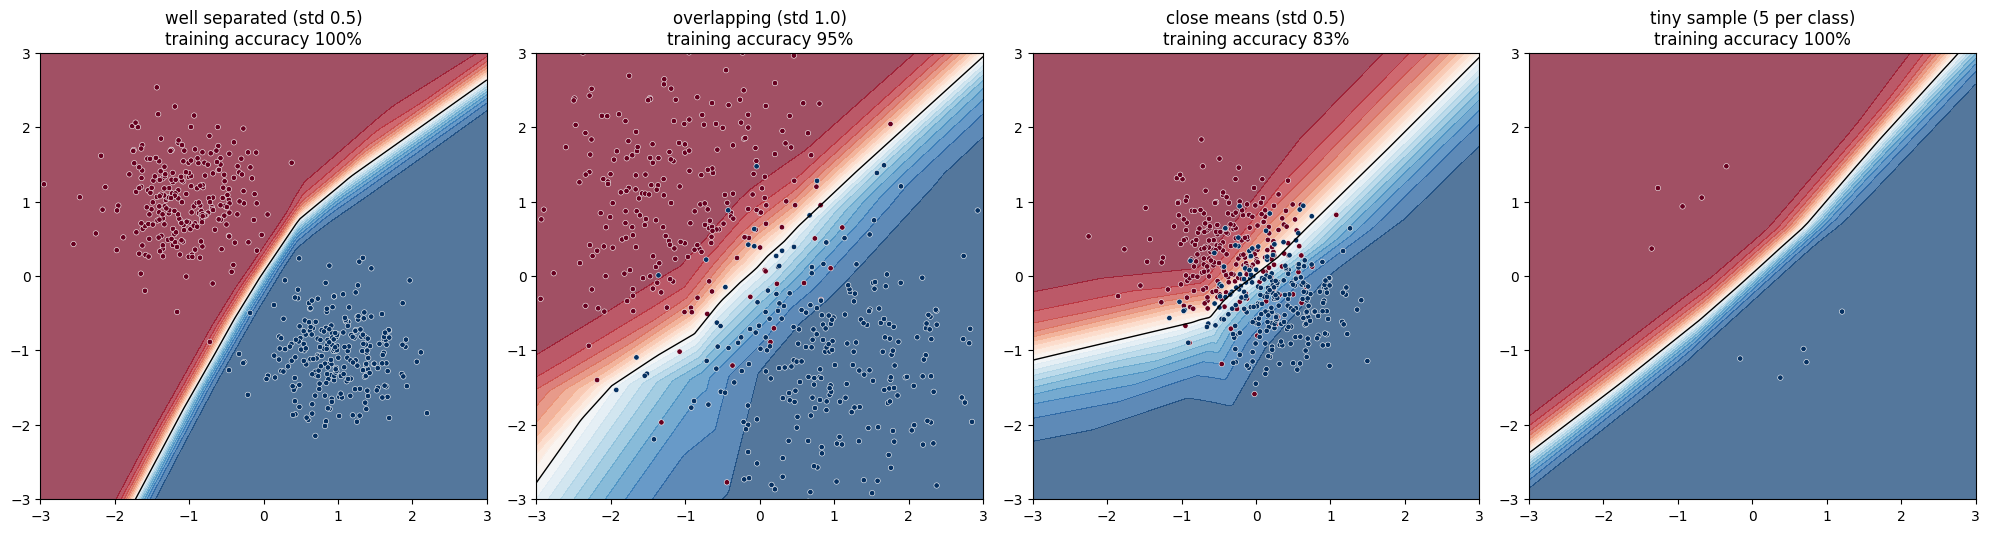

In [3]:
scenarios = [
    ("well separated (std 0.5)", [(-1, 1), (1, -1)], 0.5, 250),
    ("overlapping (std 1.0)", [(-1, 1), (1, -1)], 1.0, 250),
    ("close means (std 0.5)", [(-0.3, 0.3), (0.3, -0.3)], 0.5, 250),
    ("tiny sample (5 per class)", [(-1, 1), (1, -1)], 0.5, 5),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, means, std, n) in zip(axes, scenarios):
    X, y = gaussian_classes(means, std, n)
    model, acc = fit(mlp((16,)), X, y)
    plot_boundary(ax, model, X, y, f"{title}\ntraining accuracy {acc:.0%}")
fig.tight_layout()
plt.show()

The colour shows the predicted probability of the blue class, the black line the decision boundary (probability 0.5).

- With **well-separated** classes the network draws an almost straight line between them, the optimal boundary for two Gaussians with equal spread, and becomes very confident away from it.
- With **overlapping** classes the boundary is still roughly a line, but there is a wide band of uncertainty (pale colours), and some points are inevitably misclassified.
- With **close means** the classes overlap almost completely; no boundary can separate them well.
- With **five points per class** the network separates the training data perfectly, but the boundary is an arbitrary line among the many that would work. Far from the data it is confidently extrapolating with no evidence.

### A non-linear problem: two moons

The two-moons dataset cannot be separated by a straight line. We fit networks of increasing size and compare their training and test accuracy.

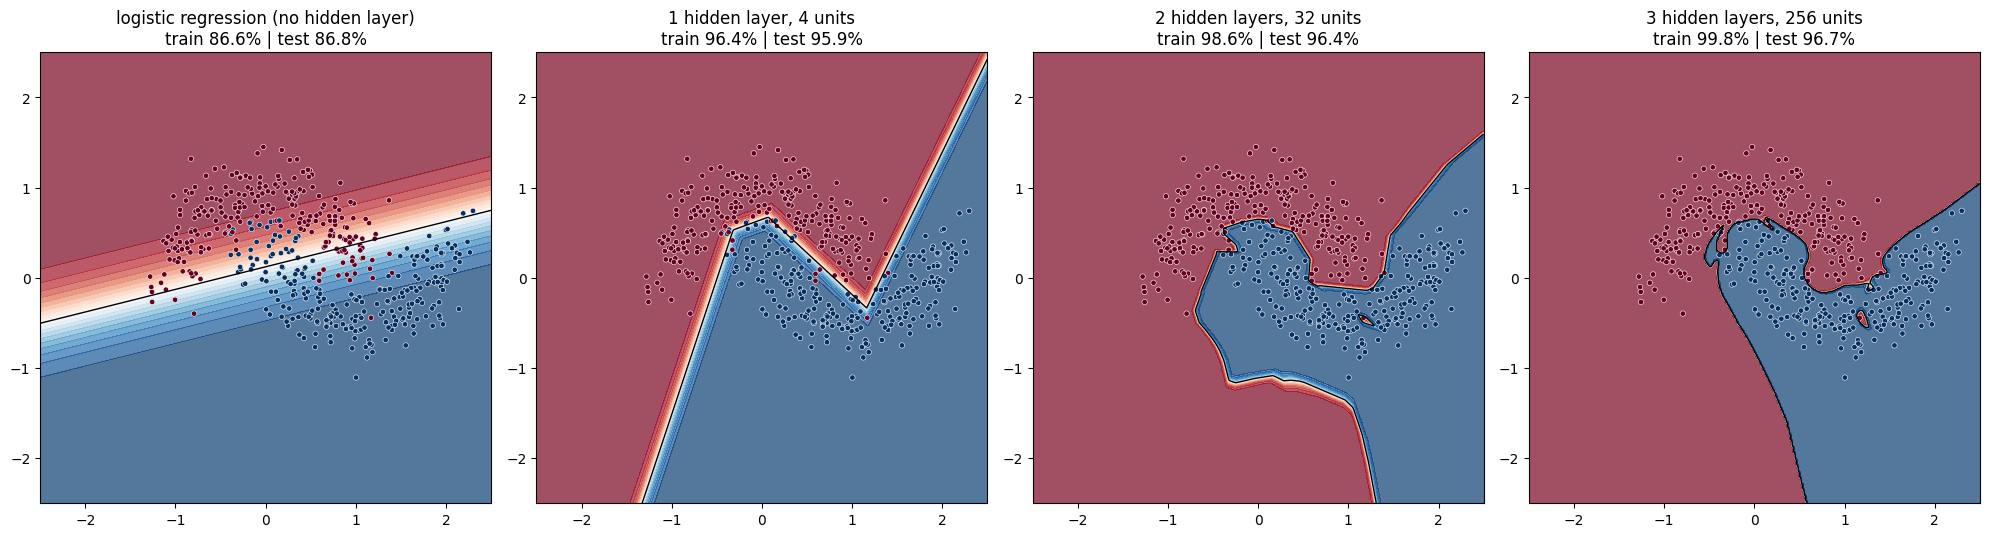

In [4]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=0)
X_moons = X_moons.astype(np.float32)
X_test_moons, y_test_moons = make_moons(n_samples=1000, noise=0.2, random_state=1)
X_test_moons = X_test_moons.astype(np.float32)

architectures = [("logistic regression (no hidden layer)", ()), ("1 hidden layer, 4 units", (4,)),
                 ("2 hidden layers, 32 units", (32, 32)), ("3 hidden layers, 256 units", (256, 256, 256))]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, hidden) in zip(axes, architectures):
    torch.manual_seed(0)
    model, train_acc = fit(mlp(hidden), X_moons, y_moons, epochs=2000)
    with torch.no_grad():
        test_acc = (model(torch.from_numpy(X_test_moons)).argmax(1).numpy() == y_test_moons).mean()
    plot_boundary(ax, model, X_moons, y_moons, f"{name}\ntrain {train_acc:.1%} | test {test_acc:.1%}", lim=2.5)
fig.tight_layout()
plt.show()

- Without hidden layers the model is **logistic regression**: its boundary is a straight line and it cannot follow the moons.
- A single hidden layer with **4 units** already bends the boundary, since each ReLU unit contributes one "fold".
- **Two hidden layers of 32 units** trace the gap between the moons closely, raising the test accuracy to about 96%.
- A **large network** trained for long enough starts fitting individual noisy points: training accuracy climbs to 99.8% and the boundary grows small islands and spikes around isolated points of the other class. The test accuracy does not improve in a meaningful way (a few tenths of a percent, within noise): the extra flexibility only memorizes noise. This is **overfitting**, and in practice it is controlled with a validation set, early stopping, or regularization.

## 2. Handwritten digit recognition (MNIST)

MNIST contains 70,000 grayscale images of handwritten digits, 28 × 28 pixels each: 60,000 for training and 10,000 for testing. We hold out the last 5,000 training images as a **validation set**, used to monitor training and choose hyperparameters. The test set is used only once, at the very end.

training: 55000, validation: 5000, test: 10000


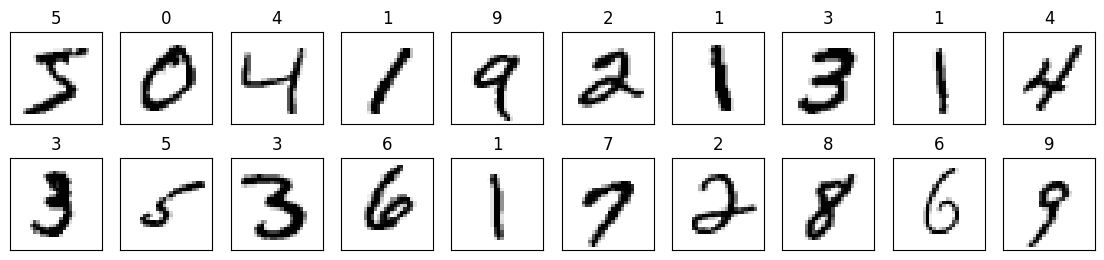

In [5]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
full_train = datasets.MNIST("data", train=True, download=True, transform=transform)
test_set = datasets.MNIST("data", train=False, download=True, transform=transform)

train_set = Subset(full_train, range(55_000))
val_set = Subset(full_train, range(55_000, 60_000))
print(f"training: {len(train_set)}, validation: {len(val_set)}, test: {len(test_set)}")

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for ax, i in zip(axes.flat, range(20)):
    image, label = full_train[i]
    ax.imshow(image.squeeze(), cmap="gray_r")
    ax.set(title=str(label), xticks=[], yticks=[])
plt.show()

The pixel values are normalized to zero mean and unit variance (the mean 0.1307 and standard deviation 0.3081 of the MNIST training pixels), for the same conditioning reasons seen in the gradient descent notebook. The network sees each image as a flat vector of 784 numbers.

### Training with validation monitoring

In [6]:
class MLP(nn.Module):
    def __init__(self, hidden=256, layers=1, dropout=0.0):
        super().__init__()
        blocks, size = [nn.Flatten()], 28 * 28
        for _ in range(layers):
            blocks += [nn.Linear(size, hidden), nn.ReLU(), nn.Dropout(dropout)]
            size = hidden
        blocks.append(nn.Linear(size, 10))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images)
            total_loss += loss_fn(logits, labels).item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            n += len(labels)
    return total_loss / n, correct / n

def train_model(model, epochs=10, lr=1e-3, batch_size=128, seed=0):
    torch.manual_seed(seed)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=1000)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(labels)
            n += len(labels)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        history.append({"epoch": epoch, "train loss": running / n, "val loss": val_loss, "val accuracy": val_acc})
    return pd.DataFrame(history).set_index("epoch")

start = time.time()
baseline = MLP(hidden=256, layers=1)
history = train_model(baseline, epochs=15)
print(f"trained in {time.time() - start:.0f} s")
history.round(4)

trained in 81 s


,train loss,val loss,val accuracy
epoch,,,
1,0.2842,0.1212,0.9690
2,0.1189,0.0877,0.9768
3,0.0764,0.0781,0.9782
4,0.0571,0.0954,0.9742
5,0.0423,0.0729,0.9804
6,0.0337,0.0799,0.9792
7,0.0262,0.0759,0.9796
8,0.0215,0.0728,0.9820
9,0.0168,0.0762,0.9810


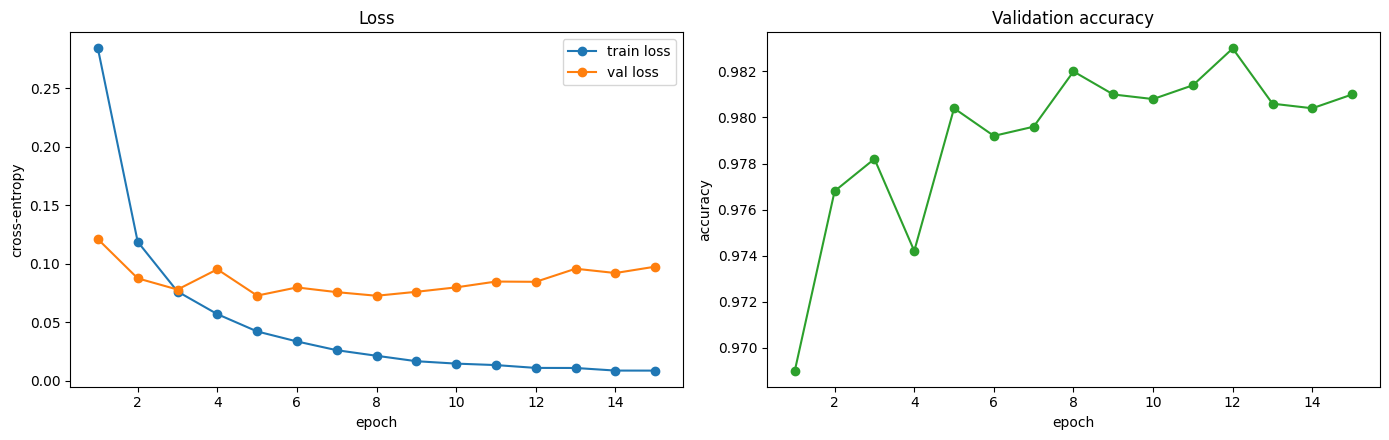

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
history[["train loss", "val loss"]].plot(ax=ax1, marker="o")
ax1.set(title="Loss", ylabel="cross-entropy")
history["val accuracy"].plot(ax=ax2, marker="o", color="tab:green")
ax2.set(title="Validation accuracy", ylabel="accuracy")
fig.tight_layout()
plt.show()

The training loss keeps decreasing, but the validation loss reaches its minimum after a few epochs and then **rises again**, while the validation accuracy plateaus. The network starts memorizing the training images: it becomes over-confident on examples it already classifies correctly, which hurts the loss on new images even when accuracy barely moves. Monitoring the validation loss is what makes this visible; the epoch with the lowest validation loss is the natural point to stop.

### A small hyperparameter search

We compare a few configurations on the validation set: network width and depth, and dropout, which randomly switches off a fraction of the units during training and acts as a regularizer.

In [8]:
configs = {
    "1 x 256": dict(hidden=256, layers=1),
    "1 x 1024": dict(hidden=1024, layers=1),
    "2 x 512": dict(hidden=512, layers=2),
    "2 x 512, dropout 0.3": dict(hidden=512, layers=2, dropout=0.3),
}
search = {}
for name, cfg in configs.items():
    hist = train_model(MLP(**cfg), epochs=10)
    best = hist["val loss"].idxmin()
    search[name] = {"best epoch": best, "val loss at best epoch": hist.loc[best, "val loss"],
                    "val accuracy at best epoch": hist.loc[best, "val accuracy"], "val accuracy, last epoch": hist["val accuracy"].iloc[-1]}
search = pd.DataFrame(search).T
search.round(4)

,best epoch,val loss at best epoch,val accuracy at best epoch,"val accuracy, last epoch"
1 x 256,8.0,0.0640,0.9828,0.9822
1 x 1024,10.0,0.0704,0.9846,0.9846
2 x 512,8.0,0.0657,0.9852,0.9812
"2 x 512, dropout 0.3",10.0,0.0636,0.9814,0.9814


All configurations end up within half a percentage point of each other (on 5,000 validation images, a difference of about 20 digits), so the choice is not critical. The network with **dropout** has the lowest validation loss, and its best epoch is the last one: unlike the others, it was still improving rather than starting to overfit. We choose it and retrain it for that number of epochs. Only then do we look at the test set.

In [9]:
best_epochs = int(search.loc["2 x 512, dropout 0.3", "best epoch"])
final = MLP(hidden=512, layers=2, dropout=0.3)
train_model(final, epochs=best_epochs)

test_loader = DataLoader(test_set, batch_size=1000)
test_loss, test_acc = evaluate(final, test_loader, nn.CrossEntropyLoss())
print(f"final model trained for {best_epochs} epochs")
print(f"test accuracy: {test_acc:.2%}  (test loss {test_loss:.4f})")

final model trained for 10 epochs
test accuracy: 98.07%  (test loss 0.0650)


Most frequent confusions (true, predicted): count
true  predicted
4     9            20
2     3             9
3     5             7
5     6             7
7     9             7


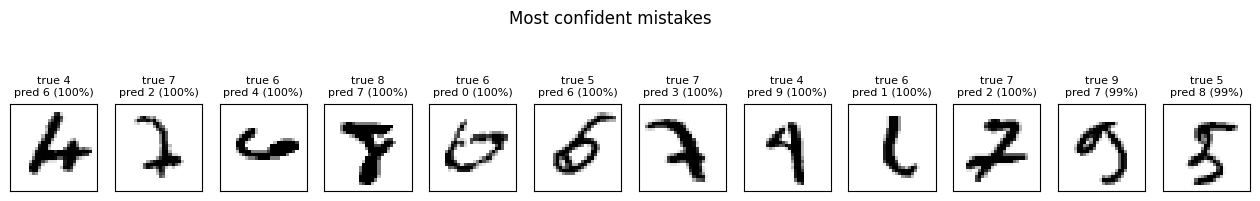

In [10]:
final.eval()
with torch.no_grad():
    logits = torch.cat([final(images) for images, _ in test_loader])
preds = logits.argmax(1)
labels = test_set.targets
confidence = torch.softmax(logits, 1).max(1).values

confusion = pd.crosstab(pd.Series(labels.numpy(), name="true"), pd.Series(preds.numpy(), name="predicted"))
off_diag = confusion.where(~np.eye(10, dtype=bool)).stack().sort_values(ascending=False).head(5)
print("Most frequent confusions (true, predicted): count")
print(off_diag.astype(int).to_string())

wrong = torch.where(preds != labels)[0]
wrong = wrong[confidence[wrong].argsort(descending=True)][:12]
fig, axes = plt.subplots(1, 12, figsize=(16, 2.2))
for ax, i in zip(axes, wrong):
    ax.imshow(test_set.data[i], cmap="gray_r")
    ax.set(title=f"true {labels[i].item()}\npred {preds[i].item()} ({confidence[i]:.0%})", xticks=[], yticks=[])
    ax.title.set_fontsize(8)
fig.suptitle("Most confident mistakes", y=1.12)
plt.show()

The final network classifies about **98% of the test digits** correctly. The remaining errors are mostly between digits that look alike (4 read as 9 by far the most often, then 2 and 3, 3 and 5, 7 and 9), and many of the most confident mistakes are images that a human would also find ambiguous or that are badly written.

A fully connected network treats the 784 pixels as an unordered list: it does not know that neighbouring pixels belong together, and the same stroke in a different position looks like a completely new input. Convolutional networks, the subject of the next notebook, build this spatial structure into the architecture.

## Summary

- Hidden layers with non-linear activations turn linear classifiers into flexible ones; **depth and width** control how complex the decision boundary can be.
- Small datasets and very large networks lead to **overfitting**: perfect training accuracy with arbitrary or noisy boundaries.
- A **validation set** is essential: it shows when to stop training and which configuration to choose, while the **test set** is used only once for the final estimate.
- **Dropout** is a simple, effective regularizer for fully connected networks.